## Data Generation - Rodrigo Michelassi

This notebook is responsible for generating the data for my bachelor thesis.

We will be running a simple dataset analysis just to decide how to deal with all the data we want to train our models and generate new data from it.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ultralytics import YOLO
from PIL import Image

### Loading detection model

In [2]:
od_model_path = '/home/rodrigocm/tcc/models/optic-disc-detection.pt'
fovea_model_path = '/home/rodrigocm/tcc/models/fovea-detection.pt'

od_model = YOLO(od_model_path)
fovea_model = YOLO(fovea_model_path)

In [3]:
import sys
sys.path.append('..')

from scripts.yolo_lib import getPredictions

img_path = '/home/rodrigocm/tcc/data/test-images'

test_image = os.path.join(img_path, 'img01859.jpg')
output_image = os.path.join(img_path, 'img01859_result.jpg')

od_results, fovea_results = getPredictions(imagePath=test_image, odModel=od_model, foveaModel=fovea_model, saveImg=True, output_path=output_image)


image 1/1 /home/rodrigocm/tcc/data/test-images/img01859.jpg: 512x640 1 optic_disc, 74.3ms
Speed: 5.1ms preprocess, 74.3ms inference, 136.7ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /home/rodrigocm/tcc/data/test-images/img01859.jpg: 512x640 1 fovea, 9.7ms
Speed: 3.1ms preprocess, 9.7ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


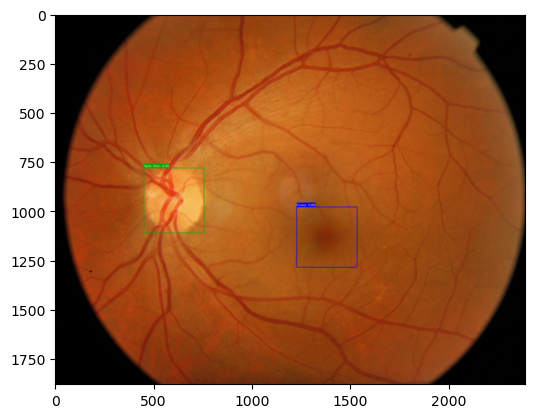

In [4]:
img = np.asarray(Image.open(output_image))
plt.imshow(img)

### Dataset Analysis

Run a simple analysis on BRSET and create a list of images that should be deleted.

We will remove images that: 
- Have a low representation in the dataset
- Have more than one disease in it

In [5]:
brset_path = '/scratch/datasets/retina/brset'

brset_df = pd.read_csv(os.path.join(brset_path, 'labels.csv'))
brset_df.head(10)

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
5,img00006,3,Canon CR,22.0,diabetes1,11,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
6,img00007,4,Canon CR,22.0,diabetes1,1,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
7,img00008,4,Canon CR,22.0,diabetes1,1,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
8,img00009,5,Canon CR,23.0,diabetes1,20,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
9,img00010,5,Canon CR,23.0,diabetes1,20,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate


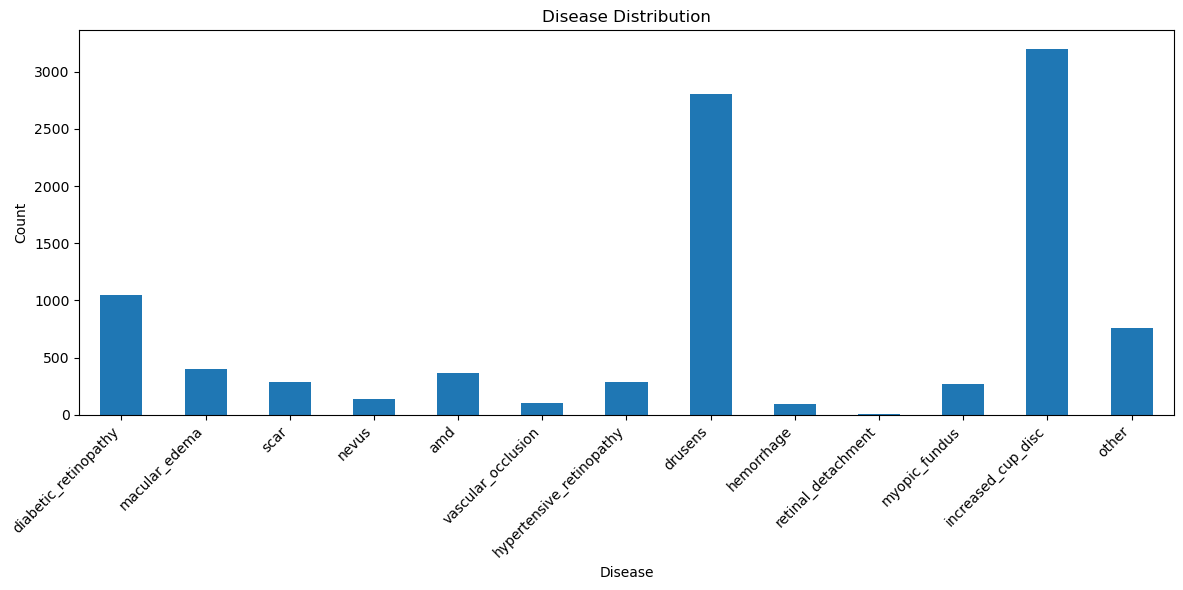

In [6]:
def disease_bar_plot(counts):
    plt.figure(figsize=(12, 6))
    counts.plot(kind='bar')

    plt.xlabel("Disease")
    plt.ylabel("Count")
    plt.title("Disease Distribution")
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

diseases_list = ['diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens', 'hemorrhage', 'retinal_detachment', 'myopic_fundus', 'increased_cup_disc', 'other']
disease_counts = brset_df[diseases_list].sum()
disease_bar_plot(disease_counts)



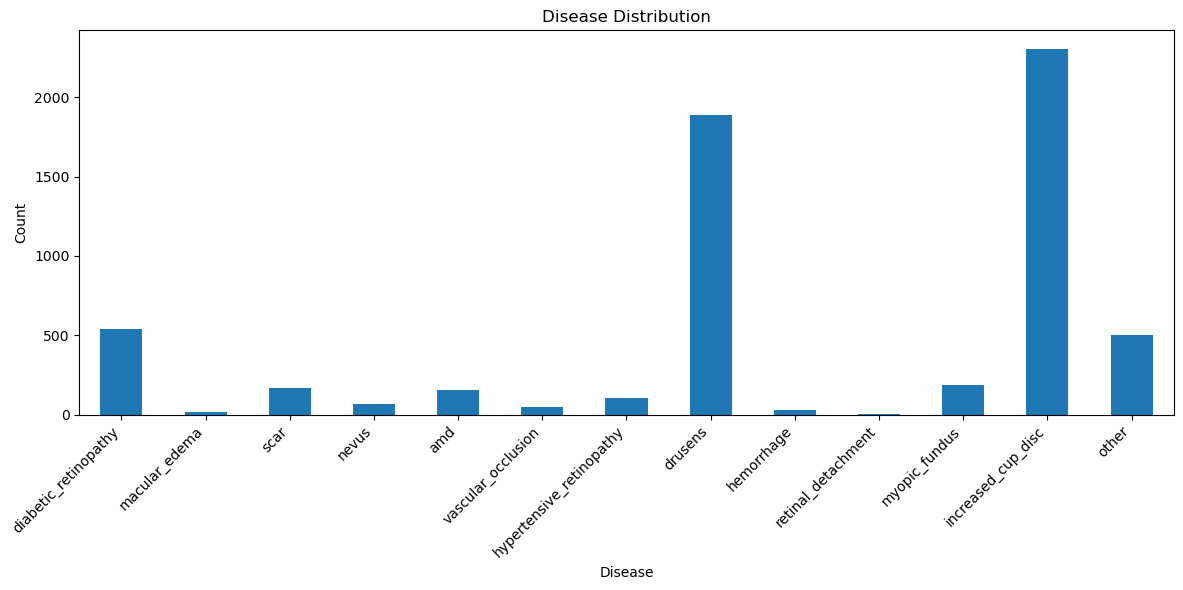

In [7]:
num_diseases_per_row = brset_df[diseases_list].sum(axis=1)

# Keep only rows with 0 or 1 disease
filtered_brset_df = brset_df[num_diseases_per_row <= 1]
filtered_disease_counts = filtered_brset_df[diseases_list].sum()
disease_bar_plot(filtered_disease_counts)

As we can see in the above bar plot, after removing images that have more than 1 disease in its classification, a few diseases are not really relevant in the dataset. Knowing this, we will remove all images that present retinal_detachment from our analysis.

We could as well remove images that present macular edema, however we are planning to run our macula detection model in the images, and maybe an image with low macula visibility is a strong signal that it presents macular edema.

We will also remove the images that carry the "other" category, since we can't really generate a great natural language description for these diseases that are not classified and may vary in a large spectrum of diseases.

In [8]:
filtered_brset_df['healthy'] = (
    filtered_brset_df[diseases_list].sum(axis=1) == 0
).astype(int)

filtered_brset_df.head()

/tmp/ipykernel_26725/914006237.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_brset_df['healthy'] = (


,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality,healthy
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,1,0,Adequate,0
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,1,0,Adequate,0
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,Adequate,1
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,Adequate,1
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,Adequate,1


In [9]:
other_abnormalities = ['retinal_detachment', 'other']

filtered_brset_df['other_abnormalities'] = (
    filtered_brset_df[other_abnormalities].sum(axis=1) > 0
).astype(int)

filtered_brset_df = filtered_brset_df.drop(
    columns=['retinal_detachment', 'other']
)

print(len(filtered_brset_df))

14477


/tmp/ipykernel_26725/3989000228.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_brset_df['other_abnormalities'] = (


### Enrich Dataset with Detection Model

In [13]:
from scripts.yolo_lib import extractInformationFromPred, getEdgeDistanceReal, determineStructureDirection

def has_detection(results):
    return len(results[0].boxes) > 0

def mark_failed_detection(df, idx):
    df.loc[idx, 'od_detection_confidence'] = np.nan
    df.loc[idx, 'od_center_x'] = np.nan
    df.loc[idx, 'od_center_y'] = np.nan
    df.loc[idx, 'od_diameter'] = np.nan
    df.loc[idx, 'od_side'] = np.nan
    df.loc[idx, 'nasal_distance'] = np.nan
    df.loc[idx, 'fovea_detection_confidence'] = np.nan
    df.loc[idx, 'fovea_center_x'] = np.nan
    df.loc[idx, 'fovea_center_y'] = np.nan
    df.loc[idx, 'temporal_distance'] = np.nan
    df.loc[idx, 'fovea_side'] = np.nan
    df.loc[idx, 'od_fovea_angle_degrees'] = np.nan

def annotate_detection_results(df, idx, od_results, fovea_results):
    od_confidence, od_center_coords, disc_diameter = extractInformationFromPred(od_results)
    fovea_confidence, fovea_center_coords, _ = extractInformationFromPred(fovea_results)

    nasal_distance, temporal_distance, od_fovea_angle_degrees = getEdgeDistanceReal(image_path, od_results[0], fovea_results[0])

    od_position = determineStructureDirection(od_results[0], image_path)
    fovea_position = determineStructureDirection(fovea_results[0], image_path)

    # Input obtained data in the dataframe
    df.loc[idx, 'od_detection_confidence'] = od_confidence
    df.loc[idx, 'od_center_x'] = od_center_coords[0]
    df.loc[idx, 'od_center_y'] = od_center_coords[1]
    df.loc[idx, 'od_diameter'] = disc_diameter
    df.loc[idx, 'od_side'] = od_position
    df.loc[idx, 'nasal_distance'] = nasal_distance
    df.loc[idx, 'fovea_detection_confidence'] = fovea_confidence
    df.loc[idx, 'fovea_center_x'] = fovea_center_coords[0]
    df.loc[idx, 'fovea_center_y'] = fovea_center_coords[1]
    df.loc[idx, 'temporal_distance'] = temporal_distance
    df.loc[idx, 'fovea_side'] = fovea_position
    df.loc[idx, 'od_fovea_angle_degrees'] = od_fovea_angle_degrees

brset_images_path = os.path.join(brset_path, 'imgs')
for idx, row in filtered_brset_df.iterrows():
    # remove this when actually running the algorithm
    print(f'Processing image {idx}')

    img_file = row['image_id'] + '.jpg'
    image_path = os.path.join(brset_images_path, img_file)
    
    # Leverage YOLO Optic Disc and Fovea detection models to gather data
    od_results, fovea_results = getPredictions(imagePath=image_path, odModel=od_model, foveaModel=fovea_model, saveImg=False)

    if not has_detection(od_results) or not has_detection(fovea_results):
        mark_failed_detection(filtered_brset_df, idx)
        continue

    annotate_detection_results(filtered_brset_df, idx, od_results, fovea_results)

    # we need to run the inference from each eye here
    # get what more data we could use to describe the picture.
    # bad illumination, bad focus, exam_eye
    # fovea visibility
    # understand these two columns: DR_ICDR DR_SDRG
        # ex: “consistent with moderate non-proliferative diabetic retinopathy (ICDR grade 2)” 
    # we should not include all these features in all the images
    # use synonyms and variations to the sentences.
    # for macula:
        # if conf > 0.8:
        #     "macula clearly visible", “the macula is well defined”
        # elif conf > 0.5:
        #     "macula is visible", “the macular region is partially visible”
        # elif conf > 0.3:
        #     "macula faintly visible", “limited visibility of the macula”
        # else:
        #     "macula not clearly visible", “macula not clearly distinguishable”
    # for each image, we can have more than one caption:
        # Image A:
        # - Caption 1: disease-focused
        # - Caption 2: anatomy-focused
        # - Caption 3: quality-focused
    # for rare diseases, instead of throwing away the images, we can join them in diverse groups.
    # run dataset analysis for this decision.

filtered_brset_df.head()

Processing image 0

image 1/1 /scratch/datasets/retina/brset/imgs/img00001.jpg: 576x640 1 optic_disc, 13.0ms
Speed: 24.3ms preprocess, 13.0ms inference, 1.5ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /scratch/datasets/retina/brset/imgs/img00001.jpg: 576x640 1 fovea, 12.1ms
Speed: 3.9ms preprocess, 12.1ms inference, 1.4ms postprocess per image at shape (1, 3, 576, 640)
Processing image 1

image 1/1 /scratch/datasets/retina/brset/imgs/img00002.jpg: 608x640 1 optic_disc, 12.3ms
Speed: 4.1ms preprocess, 12.3ms inference, 1.7ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /scratch/datasets/retina/brset/imgs/img00002.jpg: 608x640 1 fovea, 12.1ms
Speed: 4.1ms preprocess, 12.1ms inference, 1.4ms postprocess per image at shape (1, 3, 608, 640)
Processing image 2

image 1/1 /scratch/datasets/retina/brset/imgs/img00003.jpg: 608x640 1 optic_disc, 11.8ms
Speed: 3.8ms preprocess, 11.8ms inference, 1.5ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /scrat

KeyboardInterrupt: 

### Exploring obtained values

We are leveraging a few data obtained from the YOLO model that may not be the best information to carry in the model, since this is the kind of thing that is easily interchangeable. For instance, we are saving the optic disc diameter, which can be smaller or bigger, depending on how the camera was positioned when taking the photo, or which camera took the photo. The angle information may also be out of place here

In this section, we will be running a small analysis to check the behavior of these fields across the dataset, and decide whether it makes sense to use them to generate our labels.

In [ ]:
import seaborn as sns

def plot_distribution(
    df,
    column_name,
    xlabel,
    bins=40,
    figsize=(8, 5),
    kde=True
):
    data = df[column_name].dropna()

    plt.figure(figsize=figsize)

    plt.hist(data, bins=bins, color='tab:blue', density=True, alpha=0.7)
    
    sns.kdeplot(data, color='tab:blue', linestyle='-')

    plt.title(f'Distribution of {xlabel}')
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

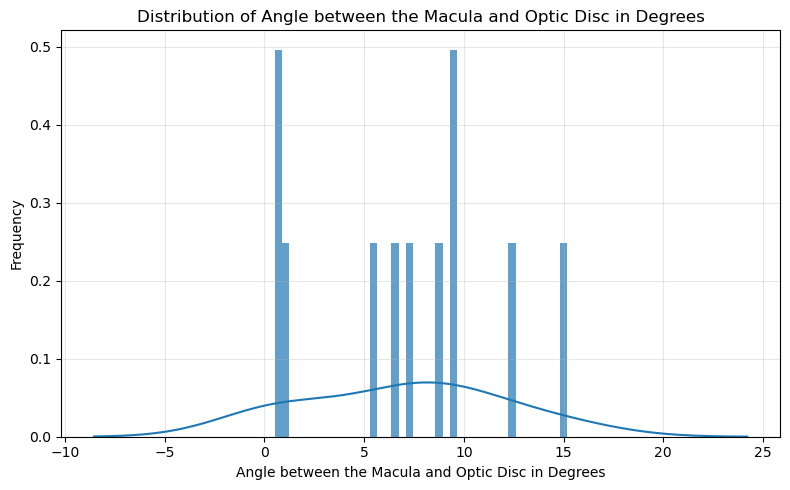

count    11.000000
mean      6.973471
std       4.870966
min       0.510954
25%       3.128057
50%       7.114277
75%       9.556931
max      15.165203
Name: od_fovea_angle_degrees, dtype: float64


In [ ]:
plot_distribution(filtered_brset_df, 'od_fovea_angle_degrees', 'Angle between the Macula and Optic Disc in Degrees')
print(filtered_brset_df['od_fovea_angle_degrees'].describe())

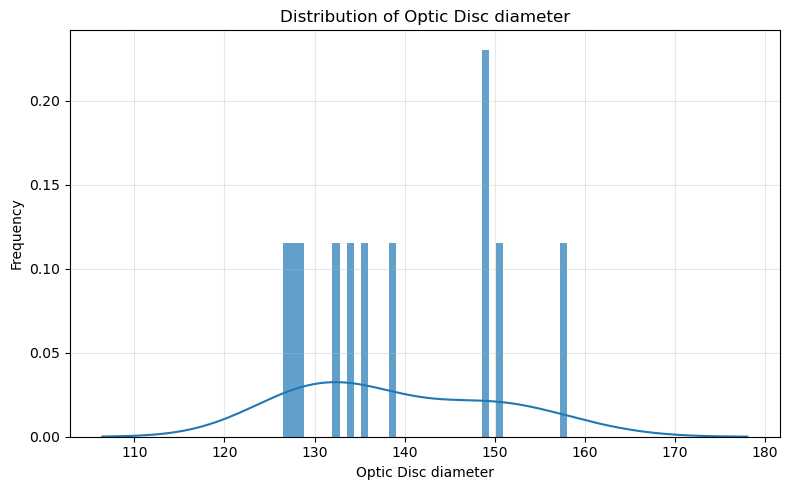

count     11.000000
mean     139.039167
std       10.773139
min      126.467270
25%      130.703125
50%      135.415100
75%      148.798576
max      158.051712
Name: od_diameter, dtype: float64


In [ ]:
plot_distribution(filtered_brset_df, 'od_diameter', 'Optic Disc diameter')
print(filtered_brset_df['od_diameter'].describe())

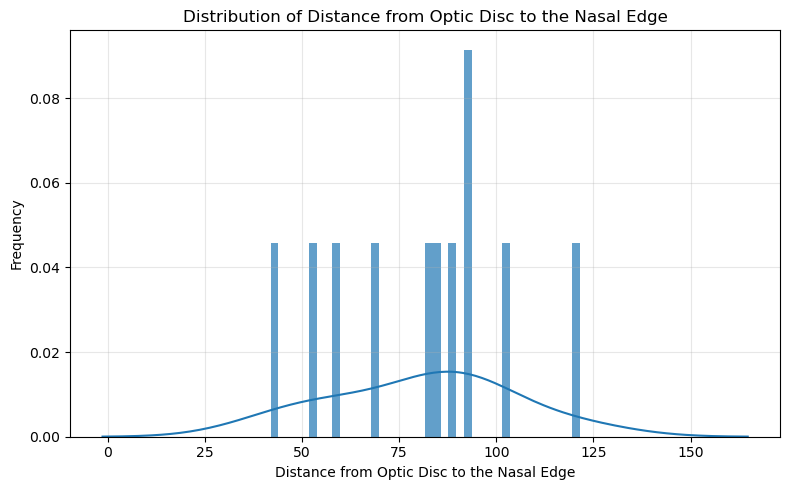

count     11.000000
mean      80.639143
std       23.278853
min       41.931997
25%       64.024600
50%       85.521280
75%       92.520387
max      121.446431
Name: nasal_distance, dtype: float64


In [ ]:
plot_distribution(filtered_brset_df, 'nasal_distance', 'Distance from Optic Disc to the Nasal Edge')
print(filtered_brset_df['nasal_distance'].describe())

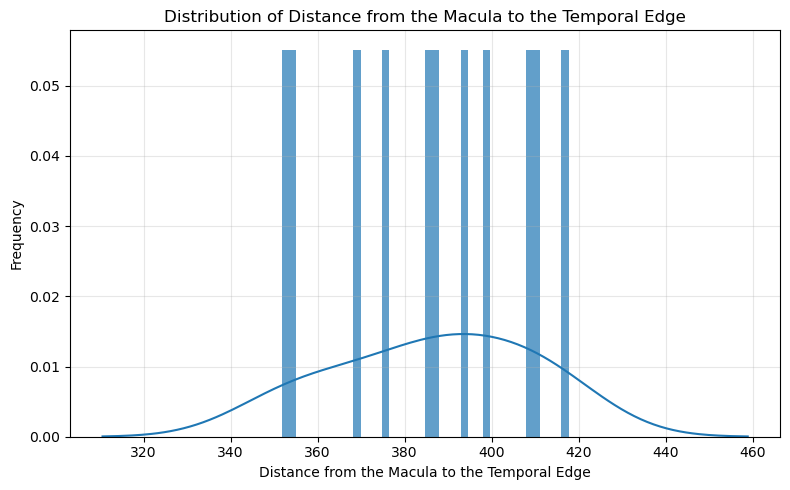

count     11.000000
mean     386.606274
std       22.161739
min      351.726205
25%      371.942312
50%      387.648895
75%      403.709234
max      417.680984
Name: temporal_distance, dtype: float64


In [ ]:
plot_distribution(filtered_brset_df, 'temporal_distance', 'Distance from the Macula to the Temporal Edge')
print(filtered_brset_df['temporal_distance'].describe())

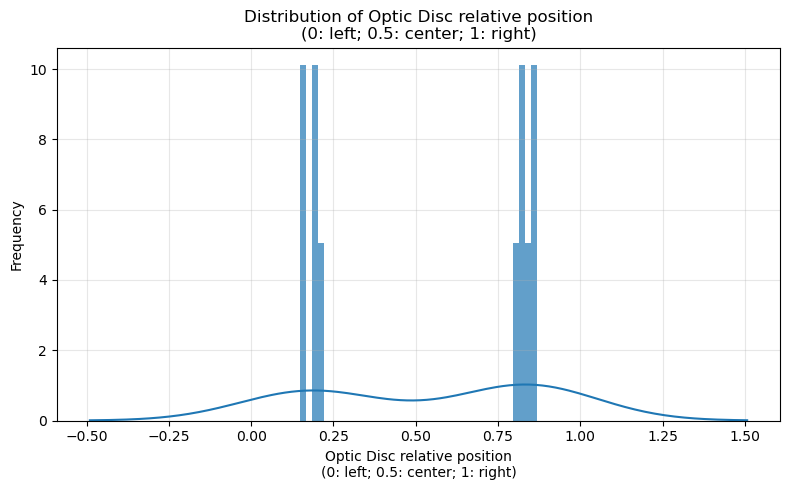

count    11.000000
mean      0.539183
std       0.343861
min       0.148434
25%       0.192800
50%       0.810850
75%       0.830156
max       0.868343
Name: od_side, dtype: float64


In [ ]:
plot_distribution(filtered_brset_df, 'od_side', 'Optic Disc relative position\n(0: left; 0.5: center; 1: right)')
print(filtered_brset_df['od_side'].describe())

### Enrich Dataset with LLM Labels

Now that we have followed through with the dataset analysis, we are ready to generate the labels we are going to use for the images. We will be integrating a public LLM system to the codebase to gather these signals and generate a label for each row.

In [ ]:
columns_to_keep = ['image_id', 'exam_eye', 'DR_ICDR', 'focus', 'iluminaton', 
                   'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 
                   'amd', 'vascular_occlusion', 'hypertensive_retinopathy', 'drusens',
                   'hemorrhage', 'myopic_fundus', 'increased_cup_disc', 'quality',
                   'healthy', 'other_abnormalities', 'od_detection_confidence',
                   'od_center_x', 'od_center_y', 'od_diameter', 'od_side',
                   'nasal_distance', 'fovea_detection_confidence', 'fovea_center_x',
                   'fovea_center_y', 'temporal_distance', 'fovea_side',
                   'od_fovea_angle_degrees']

final_brset_df = filtered_brset_df[columns_to_keep]
print(final_brset_df.columns)

Index(['image_id', 'exam_eye', 'DR_ICDR', 'focus', 'iluminaton',
       'diabetic_retinopathy', 'macular_edema', 'scar', 'nevus', 'amd',
       'vascular_occlusion', 'hypertensive_retinopathy', 'drusens',
       'hemorrhage', 'myopic_fundus', 'increased_cup_disc', 'quality',
       'healthy', 'other_abnormalities', 'od_detection_confidence',
       'od_center_x', 'od_center_y', 'od_diameter', 'od_side',
       'nasal_distance', 'fovea_detection_confidence', 'fovea_center_x',
       'fovea_center_y', 'temporal_distance', 'fovea_side',
       'od_fovea_angle_degrees'],
      dtype='object')


In [ ]:
disease_caption_columns = [
    'healthy',
    'diabetic_retinopathy',
    'macular_edema',
    'scar',
    'nevus',
    'amd',
    'vascular_occlusion',
    'hypertensive_retinopathy',
    'drusens',
    'hemorrhage',
    'myopic_fundus',
    'increased_cup_disc'
]

anatomy_caption_columns = [
    'exam_eye',
    'od_side',
    'nasal_distance',
    'temporal_distance',
    'od_fovea_angle_degrees',
    'od_diameter'
]

quality_caption_columns = [
    'focus',
    'iluminaton',
    'fovea_visibility'
]

In [ ]:
def generate_disease_prompt(row):
    # list with the name of the diseases present in the image
    findings = [
        col
        for col in disease_caption_columns
        if row[col] == 1
    ]

    if len(findings) == 0:
        findings = ["healthy"]

    metadata = "\n".join(f"- {finding}" for finding in findings)
    print(metadata)
    
    prompt = f"""
        Generate a short sentence describing the retinal findings for a given image, to describe the present
        retinal diseases or if the retina is healthy. 
        Only use the diseases given in the metadata; if the retina is healthy, metadata will contain 'healthy'.

        Image findings:
        {metadata}
        """

    return prompt

In [ ]:
def generate_anatomy_prompt(row):
    anatomy_caption_columns = [
        'exam_eye',
        'od_side',
        'nasal_distance',
        'temporal_distance',
        'od_fovea_angle_degrees',
        'od_diameter'
    ]

    prompt = f"""You are an ophthalmology assistant.

        Generate a short anatomical description of this retinal image.

        Focus on:
        - optic disc position
        - macular region
        - anatomical layout

        Do not mention diseases.
        Do not mention numeric measurements.
        
        Image findings:
        - Eye from which the photo was taken: {row['exam_eye']}
        - Optic disc location on the image: {row['od_side']}
        """

    return prompt

In [ ]:
def get_macula_visibility(fovea_confidence):
    if fovea_confidence < 0.4:
        return 'low visibility'
    elif fovea_confidence < 0.7:
        return 'partially visible'
    elif fovea_confidence < 0.9:
        return 'good visibility'
    return 'clearly visible'

def get_focus_information(focus_value):
    if focus_value == 2:
        return 'image with focus problem'
    return 'image with adequate focus'

def get_illumination_information(illumination_value):
    if illumination_value == 2:
        return 'image with bad illumination'    # extend this to have better analysis on illumination
    return 'image with adequate illumination'

def generate_quality_prompt(row):
    macula_visibility = get_macula_visibility(row['fovea_visibility'])
    focus_information = get_focus_information(row['focus'])
    illumination_information = get_illumination_information(row['iluminaton'])

    prompt = f"""You are an ophthalmology assistant.
        Generate a short sentence describing image quality.
        Focus on:
        - focus
        - illumination
        - visibility of retinal structures
        Do not mention diseases.
        Do not mention anatomy.
        Return only the sentence, no extra texts.
        
        Image findings:
        - macula visibility: {macula_visibility}
        - image focus: {focus_information}
        - image illumination: {illumination_information}.
        """

    return prompt

IndentationError: expected an indented block after 'if' statement on line 11 (702522794.py, line 13)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

SYSTEM_PROMPT = """
You are an ophthalmology assistant.

Generate concise retinal image captions.

Rules:
- Use professional medical language.
- Do not invent findings.
- Mention only information explicitly provided.
- Keep captions concise and clinically relevant.
- Output only the caption.
"""

def generate_image_caption(prompt, model, tokenizer):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=64,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        
    return response

In [ ]:
# model_name = "Qwen/Qwen2.5-3B-Instruct"

# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     torch_dtype="auto",
#     device_map="cuda"
# )
# tokenizer = AutoTokenizer.from_pretrained(model_name)

# prompt = "Give me a short introduction to large language model."
# messages = [
#     {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
#     {"role": "user", "content": prompt}
# ]
# text = tokenizer.apply_chat_template(
#     messages,
#     tokenize=False,
#     add_generation_prompt=True
# )
# model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# generated_ids = model.generate(
#     **model_inputs,
#     max_new_tokens=512
# )
# generated_ids = [
#     output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
# ]

# response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

### Save Dataset

Gets the remaining images from the dataset and their appropriate labels for CLIP and SIGLIP training to the dataset path for this project.

For CLIP and SIGLIP dataset definition, the files structure will be:

```sh
dataset/
 ├── images/
 │    ├── img1.jpg
 │    ├── img2.jpg
 │    └── ...
 └── captions.csv   (or .json / .txt)
```